In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pathlib

# Path

In [2]:
PROJECT_ROOT = pathlib.Path.cwd()
NOTEBOOK_DIR = PROJECT_ROOT/'python'/'freightCollabLeuven'
AGG_METRIC_BASE_PATH = PROJECT_ROOT/'data'/'freightCollabLeuven15Receivers'/'clean'

In [3]:
AGG_METRIC_FILEPATH = AGG_METRIC_BASE_PATH / 'all_scenarios_metrics.csv.gz'

In [11]:
penalty_dict = {
    0.0003: 1,
    0.0008: 3,
    0.0014: 5,
    0.0028: 10,
    0.0056: 20,
    0.0098: 35,
    0.014: 50
}

# Read data

In [5]:
agg_metrics_df = pd.read_csv(AGG_METRIC_FILEPATH, compression='gzip')
agg_metrics_df

,ring_level,direction,allocation_method,allocation_factor,penalty,instance,num_receivers,fleet_size,iter0_fleet_size,final_carrier_score,...,iter0_VKT_km,VTT_seconds,iter0_VTT_seconds,TKT_tonkm,iter0_TKT_tonkm,mean_receiver_dist_to_depot_euclidean_km,mean_receiver_dist_to_depot_network_km,clustering_index_euclidean_km,clustering_index_network_km,depot_to_network_center_euclidean_km
0,r0,NE,approx_shapley_mc,0.8,0.0003,0,15,2,2,822.784625,...,25.659736,21190.0,22302.0,24198.946619,18027.358948,0.468783,1.883890,0.192242,0.528353,0.255739
1,r0,NE,approx_shapley_mc,0.8,0.0003,1,15,2,2,841.818640,...,21.712036,20981.0,21597.0,24763.664434,17937.496331,0.612420,1.654723,0.239085,0.641987,0.255739
2,r0,NE,approx_shapley_mc,0.8,0.0008,0,15,2,2,840.296317,...,25.659736,21669.0,22302.0,34042.795088,18027.358948,0.468783,1.883890,0.192242,0.528353,0.255739
3,r0,NE,approx_shapley_mc,0.8,0.0008,1,15,2,2,823.919410,...,21.712036,21054.0,21597.0,25181.882467,17937.496331,0.612420,1.654723,0.239085,0.641987,0.255739
4,r0,NE,approx_shapley_mc,0.8,0.0014,0,15,2,2,772.768767,...,25.659736,21042.0,22302.0,21683.320056,18027.358948,0.468783,1.883890,0.192242,0.528353,0.255739
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1241,r9,SW,proportional,0.8,0.0008,0,15,2,2,768.693855,...,47.892707,22908.0,25875.0,43425.864838,39586.209477,2.864836,4.516734,0.192242,0.528353,2.557172
1242,r9,SW,proportional,0.8,0.0014,0,15,2,2,772.578312,...,47.892707,22908.0,25875.0,43425.864838,39586.209477,2.864836,4.516734,0.192242,0.528353,2.557172
1243,r9,SW,proportional,0.8,0.0028,0,15,2,2,769.834698,...,47.892707,22908.0,25875.0,43425.864838,39586.209477,2.864836,4.516734,0.192242,0.528353,2.557172
1244,r9,SW,proportional,0.8,0.0056,0,15,2,2,743.016387,...,47.892707,24962.0,25875.0,41249.746535,39586.209477,2.864836,4.516734,0.192242,0.528353,2.557172


## Filter useful records for analysis 

In [24]:
anls_agg_metrics_df = agg_metrics_df[agg_metrics_df['instance']==0]
anls_agg_metrics_df

,ring_level,direction,allocation_method,allocation_factor,penalty,instance,num_receivers,fleet_size,iter0_fleet_size,final_carrier_score,...,iter0_VKT_km,VTT_seconds,iter0_VTT_seconds,TKT_tonkm,iter0_TKT_tonkm,mean_receiver_dist_to_depot_euclidean_km,mean_receiver_dist_to_depot_network_km,clustering_index_euclidean_km,clustering_index_network_km,depot_to_network_center_euclidean_km
0,r0,NE,approx_shapley_mc,0.8,0.0003,0,15,2,2,822.784625,...,25.659736,21190.0,22302.0,24198.946619,18027.358948,0.468783,1.883890,0.192242,0.528353,0.255739
2,r0,NE,approx_shapley_mc,0.8,0.0008,0,15,2,2,840.296317,...,25.659736,21669.0,22302.0,34042.795088,18027.358948,0.468783,1.883890,0.192242,0.528353,0.255739
4,r0,NE,approx_shapley_mc,0.8,0.0014,0,15,2,2,772.768767,...,25.659736,21042.0,22302.0,21683.320056,18027.358948,0.468783,1.883890,0.192242,0.528353,0.255739
6,r0,NE,approx_shapley_mc,0.8,0.0028,0,15,2,2,785.973866,...,25.659736,21772.0,22302.0,25260.754733,18027.358948,0.468783,1.883890,0.192242,0.528353,0.255739
8,r0,NE,approx_shapley_mc,0.8,0.0056,0,15,2,2,801.937328,...,25.659736,22192.0,22302.0,26797.199089,18027.358948,0.468783,1.883890,0.192242,0.528353,0.255739
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1241,r9,SW,proportional,0.8,0.0008,0,15,2,2,768.693855,...,47.892707,22908.0,25875.0,43425.864838,39586.209477,2.864836,4.516734,0.192242,0.528353,2.557172
1242,r9,SW,proportional,0.8,0.0014,0,15,2,2,772.578312,...,47.892707,22908.0,25875.0,43425.864838,39586.209477,2.864836,4.516734,0.192242,0.528353,2.557172
1243,r9,SW,proportional,0.8,0.0028,0,15,2,2,769.834698,...,47.892707,22908.0,25875.0,43425.864838,39586.209477,2.864836,4.516734,0.192242,0.528353,2.557172
1244,r9,SW,proportional,0.8,0.0056,0,15,2,2,743.016387,...,47.892707,24962.0,25875.0,41249.746535,39586.209477,2.864836,4.516734,0.192242,0.528353,2.557172


In [8]:
anls_agg_metrics_df['penalty'].unique()

array([0.0003, 0.0008, 0.0014, 0.0028, 0.0056, 0.0098, 0.014 ])

In [9]:
anls_agg_metrics_df['allocation_method'].unique()

array(['approx_shapley_mc', 'approx_shapley_stratified', 'exact_shapley',
       'marginal', 'proportional'], dtype=object)

In [91]:
alloc_methods_color_dict = {
    'exact_shapley': "#1890e6",
    'approx_shapley_stratified': "#07842d",
    'approx_shapley_mc': "#ec613a",
    'proportional': "#57117a",
    'marginal': "#f274a6"
}

In [72]:
depot_dist_metric_df = pd.pivot_table(
    anls_agg_metrics_df,
    index=[
        "depot_to_network_center_euclidean_km",
        "penalty",
        "allocation_method",
        'direction'
    ],
    values=["final_carrier_score", "total_receiver_scores"],
    aggfunc=["mean", "median"]
)
depot_dist_metric_df.columns = [
    f"{agg}_{col}" for agg, col in depot_dist_metric_df.columns
]
depot_dist_metric_df = depot_dist_metric_df.reset_index()
depot_dist_metric_df

,depot_to_network_center_euclidean_km,penalty,allocation_method,direction,mean_final_carrier_score,mean_total_receiver_scores,median_final_carrier_score,median_total_receiver_scores
0,0.255739,0.0003,approx_shapley_mc,NE,822.784625,-1318.007437,822.784625,-1318.007437
1,0.255739,0.0003,approx_shapley_stratified,NE,921.168593,-1270.716796,921.168593,-1270.716796
2,0.255739,0.0003,exact_shapley,NE,846.592320,-1257.279997,846.592320,-1257.279997
3,0.255739,0.0003,marginal,NE,847.930475,-1200.626863,847.930475,-1200.626863
4,0.255739,0.0003,proportional,NE,921.986248,-1329.508597,921.986248,-1329.508597
...,...,...,...,...,...,...,...,...
1075,2.580630,0.0056,exact_shapley,SE,737.810740,-1479.973777,737.810740,-1479.973777
1076,2.580630,0.0056,marginal,SE,863.810645,-1390.883303,863.810645,-1390.883303
1077,2.580630,0.0056,proportional,SE,756.762922,-1481.578257,756.762922,-1481.578257
1078,2.580630,0.0098,approx_shapley_mc,SE,737.810740,-1500.000000,737.810740,-1500.000000


<Axes: title={'center': 'Mean Final Carrier Score vs Depot Distance \n (Allocation Method: proportional, Penalty: 0.0014)'}, xlabel='depot_to_network_center_euclidean_km', ylabel='mean_final_carrier_score'>

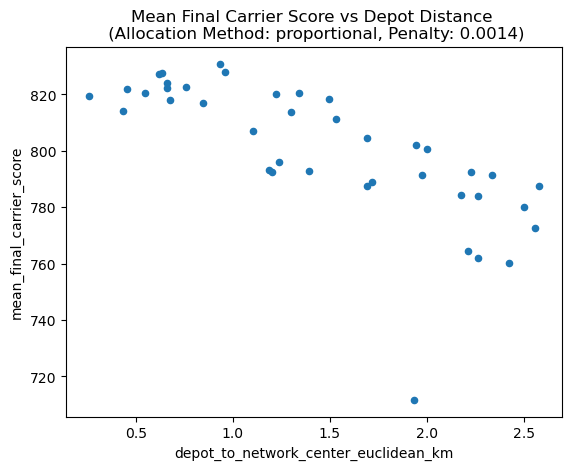

In [95]:
tem_alloc_method = list(alloc_methods_color_dict.keys())[3]
tem_plot_df = depot_dist_metric_df[
    # (depot_dist_metric_df["direction"] == "SW") & 
    (depot_dist_metric_df["allocation_method"] == f"{tem_alloc_method}") & 
    (depot_dist_metric_df["penalty"] == 0.0014)
]
tem_plot_df.plot(
    x="depot_to_network_center_euclidean_km",
    y="mean_final_carrier_score",
    kind="scatter",
    title=f"Mean Final Carrier Score vs Depot Distance \n (Allocation Method: {tem_alloc_method}, Penalty: 0.0014)",
)

In [137]:
def plot_dist_metric(
    df, alloc_method, penalty, metric_col, metric_name,
    ax=None,
    # ---- curve fitting / bending control ----
    fit_method='lowess',   # 'lowess' | 'spline' | 'poly' | None (no curve)
    smooth=0.5,            # bend level. lowess: frac in (0, 1], smaller = more bendy / local.
                           #             spline: smoothing factor s, smaller = more bendy (follows points).
                           #             poly:   polynomial degree (int), larger = more bendy.
    show_fit=True,
    # ---- point (scatter) style ----
    point_color=None,      # default: allocation-method color
    marker='o',
    point_size=50,
    point_alpha=0.85,
    edge_color='white',
    # ---- fitted-line style ----
    line_color='red',       # default: allocation-method color
    linestyle='--',
    linewidth=2.0,
    line_alpha=1.0,
    # ----- output control ----
    output_dir=None,  # if set, saves the plot to this directory with a descriptive filename
    hide_title=False,
    hide_legend=False,
    figsize=(6, 6)
):
    """Scatter a distance metric and overlay a controllable smoothed curve.

    `fit_method` chooses how the curve is built; `smooth` controls how much it
    bends to follow the data points (vs. staying smooth/straight).
    """
    default_color = alloc_methods_color_dict.get(alloc_method, "#434040")
    if point_color is None:
        point_color = default_color
    if line_color is None:
        line_color = default_color

    tem_plot_df = df[
        (df["allocation_method"] == f"{alloc_method}") &
        (df["penalty"] == penalty)
    ].sort_values("depot_to_network_center_euclidean_km")

    x = tem_plot_df["depot_to_network_center_euclidean_km"].to_numpy(dtype=float)
    y = tem_plot_df[metric_col].to_numpy(dtype=float)

    created_ax = ax is None
    if created_ax:
        fig, ax = plt.subplots(figsize=figsize)
    if not hide_title:
        ax.set_title(f'{metric_name} vs Depot Distance \n ({alloc_method}, Collab. Cost: {penalty_dict.get(penalty, penalty)})')
    ax.set_xlabel('Depot Distance (km)')
    ax.set_ylabel(metric_name)

    ax.scatter(
        x, y,
        color=point_color,
        marker=marker,
        s=point_size,
        alpha=point_alpha,
        edgecolors=edge_color,
        linewidths=0.6,
        zorder=3,
        label=metric_name,
    )

    def _fit_curve(x, y, method, smooth):
        if method == 'lowess':
            try:
                from statsmodels.nonparametric.smoothers_lowess import lowess
                fitted = lowess(y, x, frac=smooth, return_sorted=True)
                return fitted[:, 0], fitted[:, 1]
            except ImportError:
                method = 'spline'  # graceful fallback if statsmodels is missing
        if method == 'spline':
            from scipy.interpolate import UnivariateSpline
            # UnivariateSpline needs strictly increasing x -> average duplicate x
            ux, inv = np.unique(x, return_inverse=True)
            uy = np.array([y[inv == i].mean() for i in range(len(ux))])
            if len(ux) < 4:
                return ux, uy
            k = min(3, len(ux) - 1)
            spl = UnivariateSpline(ux, uy, s=smooth, k=k)
            x_fit = np.linspace(ux.min(), ux.max(), 200)
            return x_fit, spl(x_fit)
        if method == 'poly':
            deg = max(1, int(smooth))
            p = np.poly1d(np.polyfit(x, y, deg))
            x_fit = np.linspace(x.min(), x.max(), 200)
            return x_fit, p(x_fit)
        raise ValueError(f"Unknown fit_method: {method!r}")

    if show_fit and fit_method is not None and len(x) >= 3:
        x_fit, y_fit = _fit_curve(x, y, fit_method, smooth)
        ax.plot(
            x_fit, y_fit,
            color=line_color,
            linestyle=linestyle,
            linewidth=linewidth,
            alpha=line_alpha,
            zorder=2,
            label='Fitted Curve',
        )

    if not hide_legend:
        ax.legend()
    if created_ax:
        plt.show()
    if output_dir is not None:
        fig.savefig(f"{output_dir}/{metric_name.replace(' ', '_')}-{alloc_method}-CollabCost{penalty}-af{80}.png", dpi=300, bbox_inches='tight')
    return ax


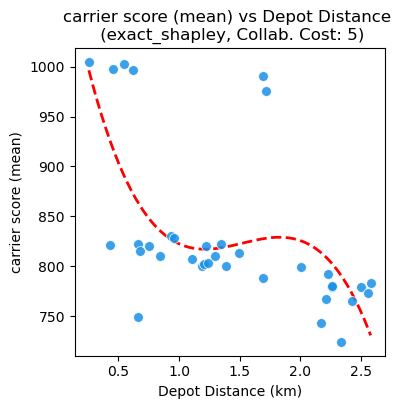

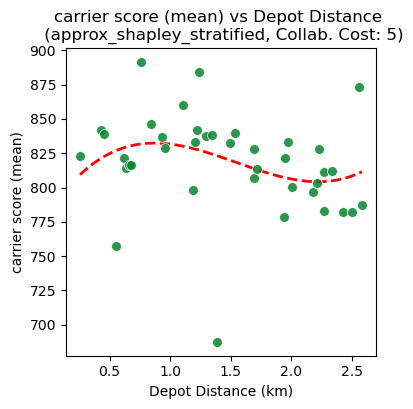

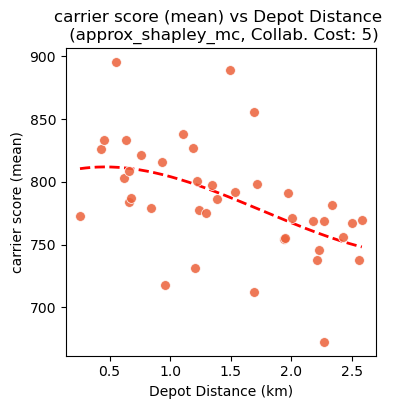

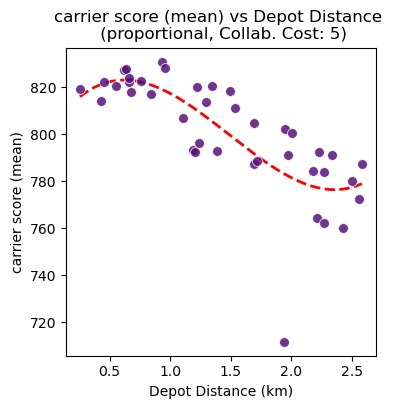

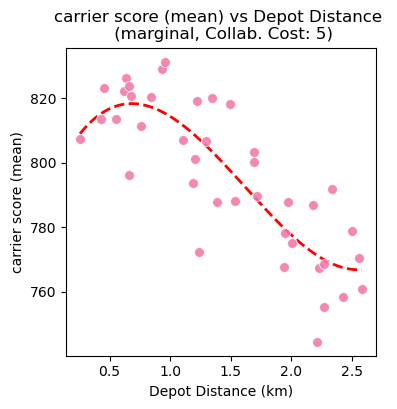

In [139]:
# _tem_alloc_method = list(alloc_methods_color_dict.keys())[4]
for _alloc_method in alloc_methods_color_dict.keys():
  plot_dist_metric( df=depot_dist_metric_df, 
                  alloc_method=_alloc_method,
                    penalty=0.0014, 
                    metric_col='mean_final_carrier_score', 
                    metric_name='carrier score (mean)',
                    fit_method='spline',
                    smooth=500000,
                    # output_dir=r'F:\OneDrive\KU Leuven\NotesObsidian\Discussion with Johan\DiscussionMaterials\22June2026',
                    figsize=(4, 4),
                    # hide_title=True,
                    hide_legend=True
                    )

In [21]:
def derive_scenarios_set_df(df,
                            ring_level,
                            direction,
                            allocation_method,
                            af,
                            penalty,
                            instance,
                            ):

    def wrap_list(factor, df, factor_name=None):
        if factor is None:
            # use all unique values present in the column
            values = df[factor_name].unique()
        elif isinstance(factor, (list, tuple, set, pd.Series, np.ndarray)):
            values = factor
        else:
            # a single scalar (int, float, str, ...) -> wrap, don't iterate
            values = [factor]
        return [str(x) for x in values]

    ring_level = wrap_list(ring_level, df, factor_name='ring_level')
    direction = wrap_list(direction, df, factor_name='direction')
    allocation_method = wrap_list(allocation_method, df, factor_name='allocation_method')
    af = wrap_list(af, df, factor_name='allocation_factor')
    penalty = wrap_list(penalty, df, factor_name='penalty')
    instance = wrap_list(instance, df, factor_name='instance')

    scenarios_set_df = df[
        (df['ring_level'].astype(str).isin(ring_level)) &
        (df['direction'].astype(str).isin(direction)) &
        (df['allocation_method'].astype(str).isin(allocation_method)) &
        (df['allocation_factor'].astype(str).isin(af)) &
        (df['penalty'].astype(str).isin(penalty)) &
        (df['instance'].astype(str).isin(instance))
    ]

    return scenarios_set_df

In [32]:
def plot_ring_cost_savings(df, direction, allocation_method, af, penalty):
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.set_title(f'Total Cost Savings by Ring Level \n (Direction: {direction}, Allocation Method: {allocation_method}, AF: {af}, Penalty: {penalty})')
    ax.set_xlabel('Ring Level')
    ax.set_ylabel('Total Cost Savings')
    ax.plot(df['ring_level'], df['total_cost_savings'], marker='o', label='Total Cost Savings')
    plt.show()


In [56]:
def plot_ring_feature(df, direction, allocation_method, af, penalty, feature_col, feature_name):
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.set_title(f'{feature_name} by Ring Level \n (Direction: {direction}, Allocation Method: {allocation_method}, AF: {af}, Penalty: {penalty})')
    ax.set_xlabel('Ring Level')
    ax.set_ylabel(feature_name)
    ax.plot(df['ring_level'], df[feature_col], marker='o', label=feature_name)
    # ax.legend()
    plt.show()

In [54]:
def plot_ring_increased_scores(df, direction, allocation_method, af, penalty,
                               save_plot_dir=None,   
                               ):
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.set_title(f'Increased Scores by Ring Level \n (Direction: {direction}, Allocation Method: {allocation_method}, AF: {af}, Penalty: {penalty})')
    ax.set_xlabel('Ring Level')
    ax.set_ylabel('Scores Increase')
    df_plot = df.copy()
    df_plot['carrier_score_increase'] = df_plot['final_carrier_score'] - df_plot['iter0_carrier_score']
    df_plot['receiver_score_increase'] = df_plot['total_receiver_scores'] + 1500

    ax.plot(df_plot['ring_level'], df_plot['carrier_score_increase'], 
            marker='o', 
            color="#4ca5e4",
            label='Carrier score increase')
    ax.plot(df_plot['ring_level'], df_plot['receiver_score_increase'], 
            marker='o', 
            color="#f0903b",
            label='Receiver score increase')
    ax.legend()     
    plt.show()

# explore the final carrier scores

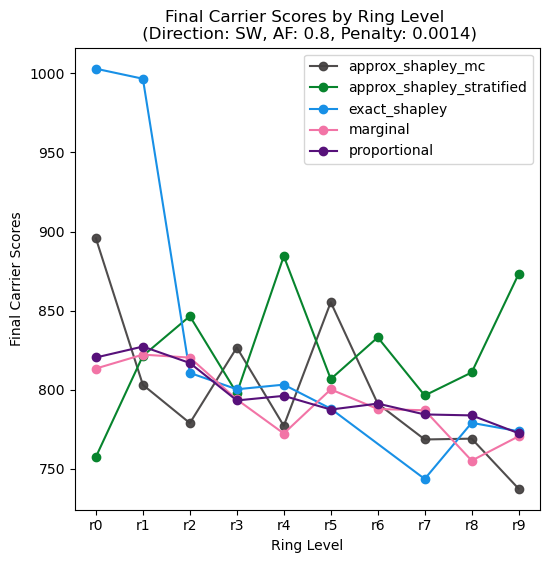

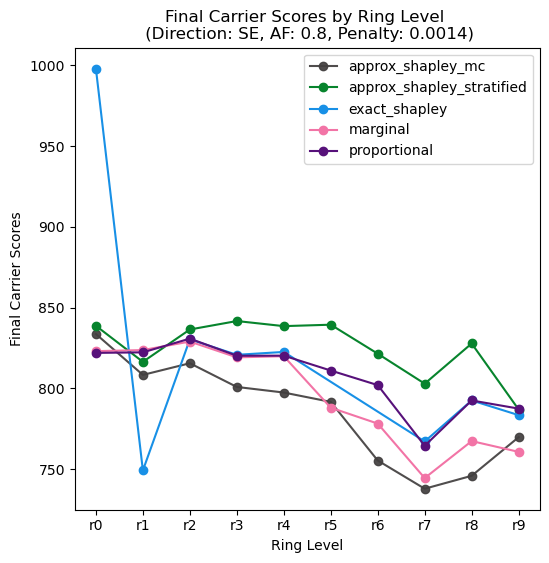

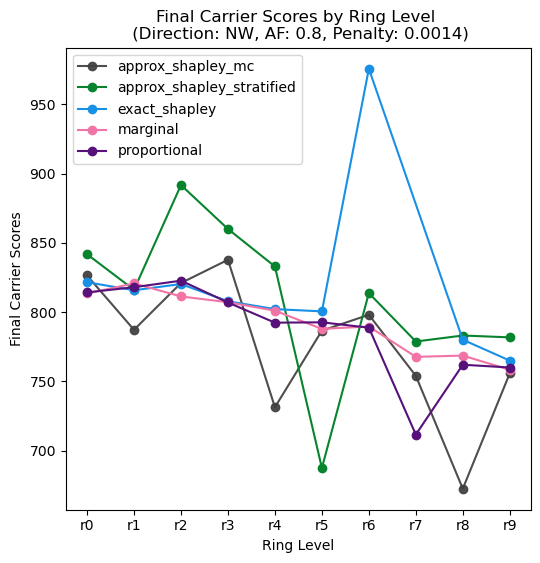

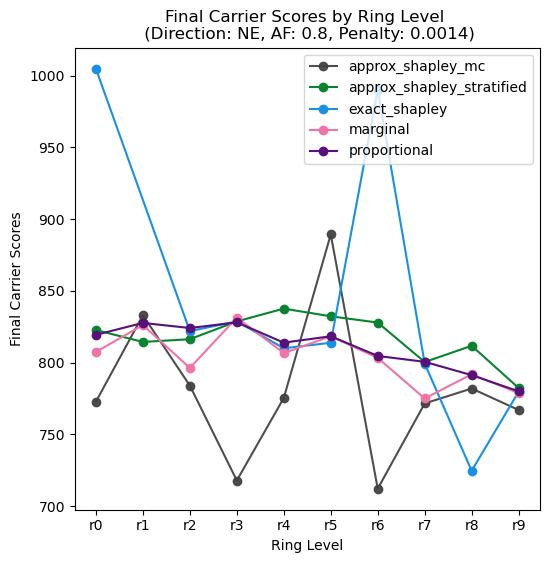

In [61]:
for direction in ['SW', 'SE', 'NW', 'NE']:
    af = 0.8
    penalty = 0.0014
    instance = 0
    scenarios_df = derive_scenarios_set_df(anls_agg_metrics_df,
                                          ring_level=None,
                                          direction=direction,
                                          allocation_method=None,
                                          af=af,
                                          penalty=penalty,
                                          instance=instance
                                          )
    ''' Plot the final carrier scores across ring levels for each direction and allocation method '''
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.set_title(f'Final Carrier Scores by Ring Level \n (Direction: {direction}, AF: {af}, Penalty: {penalty})')
    ax.set_xlabel('Ring Level')
    ax.set_ylabel('Final Carrier Scores')

    for allocation_method in scenarios_df['allocation_method'].unique():
        df_plot = scenarios_df[scenarios_df['allocation_method'] == allocation_method]
        ax.plot(df_plot['ring_level'], df_plot['final_carrier_score'], 
                marker='o', 
                color=alloc_methods_color_dict.get(allocation_method, "#434040EE"),
                label=f'{allocation_method}')
    ax.legend()
    plt.show()

# Test

In [47]:
''' Fixed direction-NW, allocation_method-exact_shapley, af-0.8, penalty-0.0014, instance-0 '''
test_SW_approx_shap_stratified_10p_scenarios_df = derive_scenarios_set_df(anls_agg_metrics_df,
                                                              ring_level=None,
                                                                direction='SW',
                                                                allocation_method='approx_shapley_stratified',
                                                                af=0.8,
                                                                penalty=0.0028,
                                                                instance=0
                                                                )
test_SW_approx_shap_stratified_10p_scenarios_df

,ring_level,direction,allocation_method,allocation_factor,penalty,instance,num_receivers,fleet_size,iter0_fleet_size,final_carrier_score,...,iter0_VKT_km,VTT_seconds,iter0_VTT_seconds,TKT_tonkm,iter0_TKT_tonkm,mean_receiver_dist_to_depot_euclidean_km,mean_receiver_dist_to_depot_network_km,clustering_index_euclidean_km,clustering_index_network_km,depot_to_network_center_euclidean_km
176,r0,SW,approx_shapley_stratified,0.8,0.0028,0,15,2,2,814.167843,...,27.103982,20981.0,22571.0,27772.889445,22953.671207,0.934711,2.381082,0.192242,0.528353,0.549082
356,r1,SW,approx_shapley_stratified,0.8,0.0028,0,15,2,2,828.342113,...,27.168741,20893.0,22547.0,26217.330357,22317.041932,1.005308,2.288003,0.192242,0.528353,0.617795
467,r2,SW,approx_shapley_stratified,0.8,0.0028,0,15,2,2,815.891491,...,29.367829,21170.0,22916.0,29609.329077,24939.406698,1.210711,2.543154,0.192242,0.528353,0.843477
580,r3,SW,approx_shapley_stratified,0.8,0.0028,0,15,2,2,798.609763,...,36.445286,22333.0,24002.0,38462.678853,30794.319320,1.540963,3.300455,0.192242,0.528353,1.185109
690,r4,SW,approx_shapley_stratified,0.8,0.0028,0,15,2,2,806.401684,...,35.272284,22225.0,23823.0,37730.278504,30139.873197,1.590832,3.239180,0.192242,0.528353,1.239447
795,r5,SW,approx_shapley_stratified,0.8,0.0028,0,15,2,2,796.041829,...,37.850468,22374.0,24111.0,41998.436529,34526.629932,2.021091,3.450359,0.192242,0.528353,1.690860
899,r6,SW,approx_shapley_stratified,0.8,0.0028,0,15,2,2,778.676538,...,39.857627,22108.0,24542.0,37246.826644,33422.378330,2.273587,3.699958,0.192242,0.528353,1.972868
1004,r7,SW,approx_shapley_stratified,0.8,0.0028,0,15,2,2,776.753858,...,42.993094,22381.0,25003.0,40771.875376,36597.408405,2.502073,4.006623,0.192242,0.528353,2.174371
1119,r8,SW,approx_shapley_stratified,0.8,0.0028,0,15,2,2,812.766237,...,44.350429,22573.0,25320.0,41212.826960,37262.541631,2.558567,4.170035,0.192242,0.528353,2.264985
1228,r9,SW,approx_shapley_stratified,0.8,0.0028,0,15,2,2,794.658828,...,47.892707,23405.0,25875.0,45439.830546,39586.209477,2.864836,4.516734,0.192242,0.528353,2.557172


# Plot depot location and receivers

In [149]:
import geopandas as gpd
import sys

# Add the project root to the system path to allow imports from the project
sys.path.append(str(PROJECT_ROOT/'python'/'test'))

import leuven_demand_generator

In [143]:
network = gpd.read_file(PROJECT_ROOT/'data'/'GemeenteLeuvenWithHbefaType'/'car_network_cropped.geojson')
network

,length,freespeed,capacity,permlanes,oneway,modes,link_id,from_node,to_node,geometry
0,24.720141,33.333333,2666.666667,3.5,1,"car,pt",1001151695_0,9241099977,18251127,"LINESTRING (172118.160 174755.065, 172107.763 ..."
1,5.046170,33.333333,1666.666667,3.5,1,"car,pt",1001151697_0,9241099976,18251127,"LINESTRING (172106.763 174737.585, 172107.763 ..."
2,33.915561,33.333333,2666.666667,3.5,1,"bike,car,walk",1001180293_0,3660306664,7578784531,"LINESTRING (171722.933 174816.222, 171689.210 ..."
3,33.915561,33.333333,2666.666667,3.5,1,"bike,car,walk",1001180293_r_0,7578784531,3660306664,"LINESTRING (171689.210 174819.819, 171722.933 ..."
4,32.341276,33.333333,2666.666667,3.5,1,"bike,car",100189221_0-303430718_0-303430717_0,1088339997,1088339799,"LINESTRING (173574.402 172841.118, 173561.096 ..."
...,...,...,...,...,...,...,...,...,...,...
20460,118.362451,33.333333,2666.666667,3.5,1,"bike,car",splitLink_98508213_r_0_2,splitNode_98508213_r_0_1,8771046269,"LINESTRING (174480.276 175237.168, 174497.468 ..."
20461,156.973685,33.333333,2666.666667,6.0,1,"bike,car",splitLink_9904064_1_1,80592606,splitNode_9904064_1_1,"LINESTRING (175048.590 172790.987, 174985.242 ..."
20462,156.973685,33.333333,2666.666667,6.0,1,"bike,car",splitLink_9904064_1_2,splitNode_9904064_1_1,2164607730,"LINESTRING (174985.242 172934.604, 174921.893 ..."
20463,156.973685,33.333333,2666.666667,6.0,1,"bike,car",splitLink_9904064_r_1_1,2164607730,splitNode_9904064_r_1_1,"LINESTRING (174921.893 173078.221, 174985.242 ..."


<Axes: >

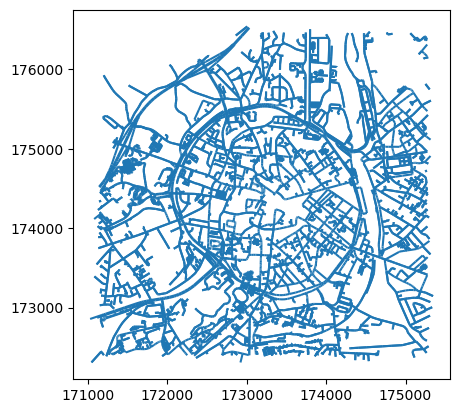

In [144]:
network.plot()

In [150]:
carrier_depots, receiver_locs = leuven_demand_generator.read_scenario_carriers_and_receivers(
    clean_dir = PROJECT_ROOT/'data'/'freightCollabLeuven15Receivers'/'clean'
)

2026-06-21 22:10:45,407 [INFO] leuven_demand_generator: Read 40 unique depots and 15 receivers from 1246 scenario folders under f:\gitRepository\matsim-libs-2024\data\freightCollabLeuven15Receivers\clean.


<Axes: title={'center': 'All depots (40) & receivers'}, xlabel='X (m, EPSG:31370)', ylabel='Y (m, EPSG:31370)'>

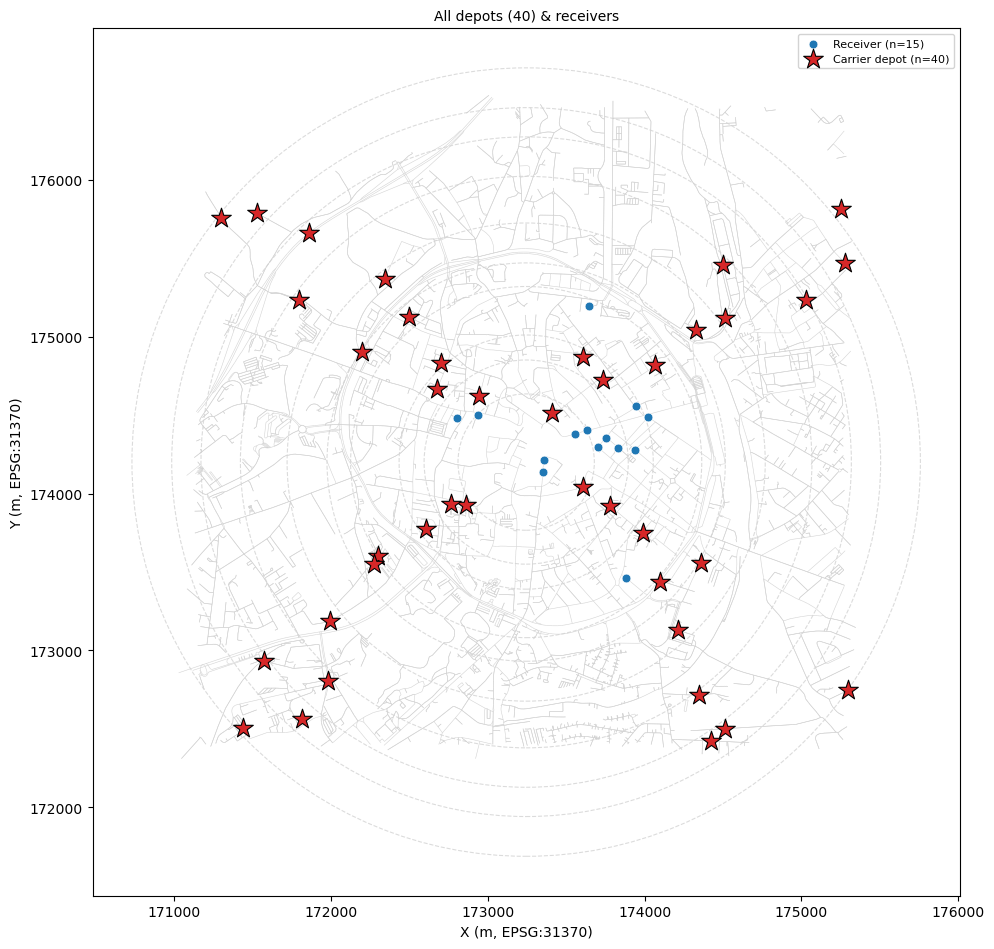

In [153]:
leuven_demand_generator.plot_scenario_positions(
    carriers_gdf=carrier_depots,
    receivers_gdf=receiver_locs,
    network_gdf=network
)